# E commerce sales analysis system


## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn


# Step 1 — Install Required Libraries

```bash
pip install pandas numpy matplotlib scikit-learn openpyxl
```


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Step 2 — Load Dataset From Your System

sales_df = pd.read_excel(
    'Regional Sales Dataset.xlsx',
    sheet_name='Sales Orders'
)

sales_df.head()


,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270


In [3]:
print("Dataset Shape:")
print(sales_df.shape)

print("\nColumn Names:")
print(sales_df.columns)

print("\nDataset Information:")
print(sales_df.info())


Dataset Shape:
(64104, 12)

Column Names:
Index(['OrderNumber', 'OrderDate', 'Customer Name Index', 'Channel',
       'Currency Code', 'Warehouse Code', 'Delivery Region Index',
       'Product Description Index', 'Order Quantity', 'Unit Price',
       'Line Total', 'Total Unit Cost'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   OrderNumber                64104 non-null  object        
 1   OrderDate                  64104 non-null  datetime64[ns]
 2   Customer Name Index        64104 non-null  int64         
 3   Channel                    64104 non-null  object        
 4   Currency Code              64104 non-null  object        
 5   Warehouse Code             64104 non-null  object        
 6   Delivery Region Index      64104 non-null  int64   

In [4]:
print(sales_df.isnull().sum())


OrderNumber                  0
OrderDate                    0
Customer Name Index          0
Channel                      0
Currency Code                0
Warehouse Code               0
Delivery Region Index        0
Product Description Index    0
Order Quantity               0
Unit Price                   0
Line Total                   0
Total Unit Cost              0
dtype: int64


In [5]:
sales_df['OrderDate'] = pd.to_datetime(sales_df['OrderDate'])

sales_df['Month'] = sales_df['OrderDate'].dt.month
sales_df['Year'] = sales_df['OrderDate'].dt.year


In [6]:
sales_df['Profit'] = (
    sales_df['Line Total'] -
    (sales_df['Total Unit Cost'] * sales_df['Order Quantity'])
)

sales_df.head()


,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Month,Year,Profit
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,1,2014,4048.542
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,1,2014,11899.602
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,1,2014,1760.760
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,1,2014,9166.136
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,1,2014,8249.040


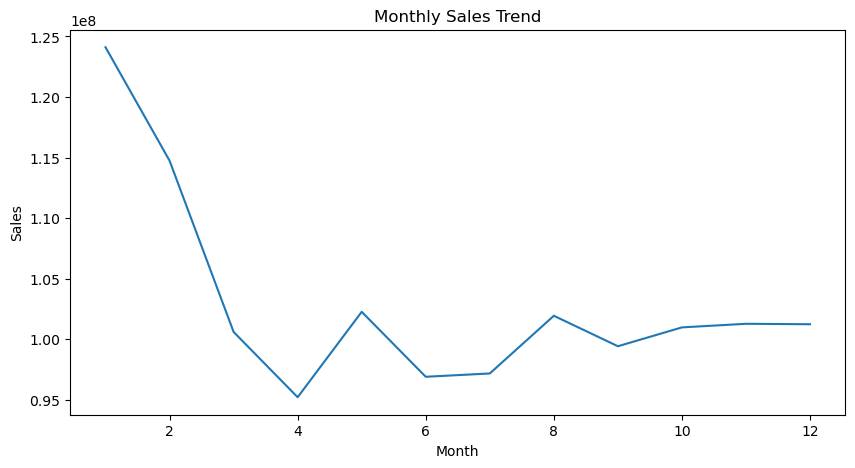

In [7]:
monthly_sales = sales_df.groupby('Month')['Line Total'].sum()

plt.figure(figsize=(10,5))

plt.plot(monthly_sales.index, monthly_sales.values)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.show()


In [8]:
X = sales_df[[
    'Order Quantity',
    'Unit Price',
    'Month',
    'Year'
]]

y = sales_df['Line Total']


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [10]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

model.fit(X_train, y_train)


RandomForestRegressor()

In [11]:
predictions = model.predict(X_test)

print(predictions[:10])


[28381.2   8522.4  13601.   23919.    7195.8  41473.   57948.3   8897.6
 30954.    3816.32]


In [12]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print('Mean Absolute Error:', mae)
print('R2 Score:', r2)


Mean Absolute Error: 0.5392295452903919
R2 Score: 0.9999999574203557


In [13]:
comparison = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': predictions
})

comparison.head(10)


,Actual Sales,Predicted Sales
0,28381.2,28381.20
1,8522.4,8522.40
2,13601.0,13601.00
3,23919.0,23919.00
4,7195.8,7195.80
5,41486.4,41473.00
6,57948.3,57948.30
7,8897.6,8897.60
8,30954.0,30954.00
9,3819.0,3816.32


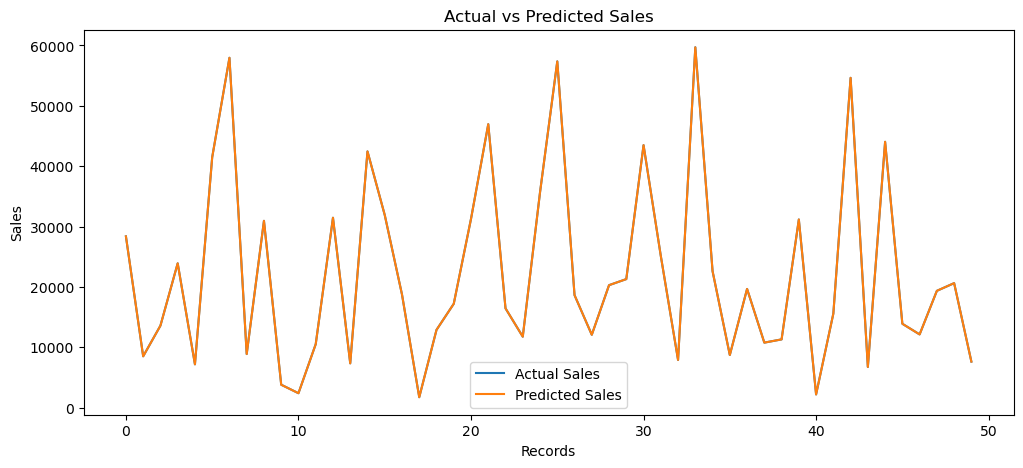

In [14]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values[:50], label='Actual Sales')
plt.plot(predictions[:50], label='Predicted Sales')

plt.title('Actual vs Predicted Sales')
plt.xlabel('Records')
plt.ylabel('Sales')

plt.legend()

plt.show()


In [15]:
future_data = [[10, 1500, 6, 2026]]

future_prediction = model.predict(future_data)

print('Future Predicted Sales:', future_prediction)


Future Predicted Sales: [13399.33]


c:\Users\khant\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [16]:
X_profit = sales_df[[
    'Order Quantity',
    'Unit Price',
    'Month',
    'Year'
]]

y_profit = sales_df['Profit']


In [17]:
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_profit,
    y_profit,
    test_size=0.2,
    random_state=42
)


In [18]:
profit_model = RandomForestRegressor()

profit_model.fit(X_train_p, y_train_p)


RandomForestRegressor()

In [19]:
profit_predictions = profit_model.predict(X_test_p)

print(profit_predictions[:10])


[11631.93432     4261.05528     7226.3989      6174.78633
  3678.55728    16903.03068    22474.544052    2659.57625175
 15408.87373     1340.9849    ]


In [20]:
future_profit = profit_model.predict([[10, 1500, 6, 2026]])

print('Predicted Future Profit:', future_profit)


Predicted Future Profit: [5041.2676]


c:\Users\khant\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


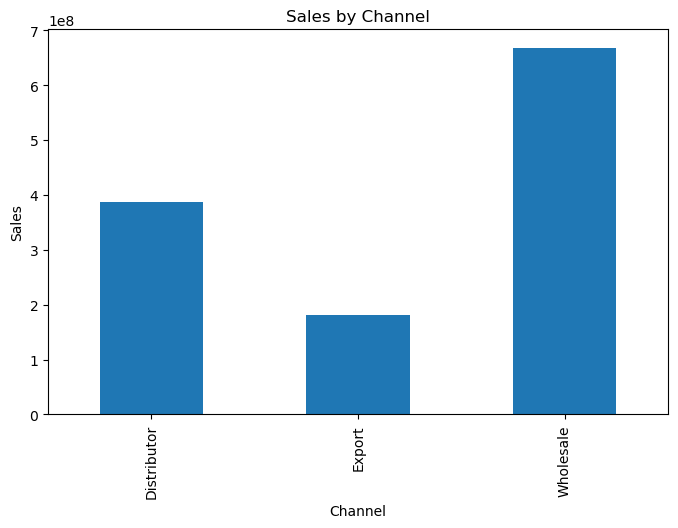

In [21]:
channel_sales = sales_df.groupby('Channel')['Line Total'].sum()

channel_sales.plot(kind='bar', figsize=(8,5))

plt.title('Sales by Channel')
plt.xlabel('Channel')
plt.ylabel('Sales')

plt.show()


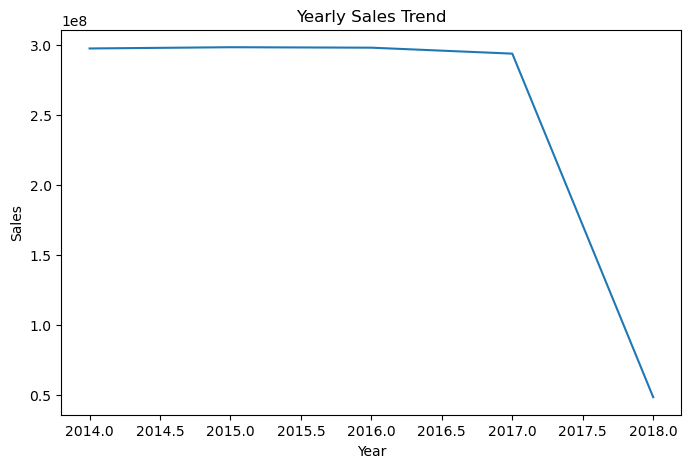

In [22]:
yearly_sales = sales_df.groupby('Year')['Line Total'].sum()

plt.figure(figsize=(8,5))

plt.plot(yearly_sales.index, yearly_sales.values)

plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Sales')

plt.show()


In [ ]:
sales_df.to_excel('clean_sales_data.xlsx', index=False)

print('Clean dataset saved successfully')


Clean dataset saved successfully


: 